In [13]:
import numpy as np
import matplotlib.pyplot as plt

from astropy import units as u

from prism.data import Cube
import prism.modeling.models as models
import prism.modeling.fitting as fitting
from prism.modeling.fitting import tie

In [14]:
# Load the data cube
filename = "data/linescube.fits"
cube = Cube.from_fits(filename)

# # If you want to bring the cube to rest-frame
# cube.zcorrect(redshift)

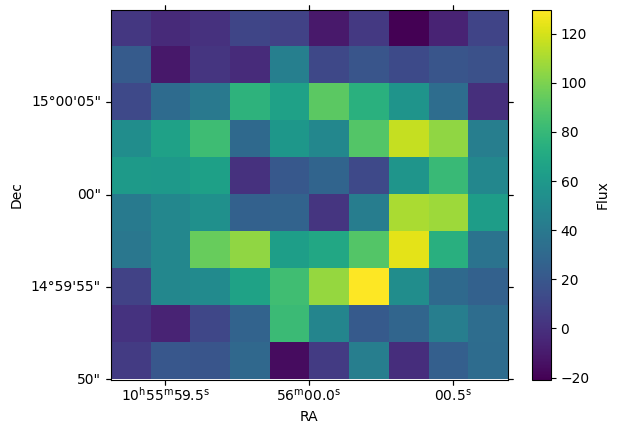

In [15]:
img = cube.to_image() # Collapse spectral axis to get 2D image

fig, ax = plt.subplots(subplot_kw={'projection': cube.wcs.celestial})

ax.imshow(img.data, origin="lower", aspect="auto", cmap="viridis")
fig.colorbar(ax.images[0], ax=ax, label="Flux")

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
plt.show()

In [16]:
# Setup the model
# The model setup can be as complex as you want!
# See 'Model Single Spectrum.ipynb' for examples of more complex models.

# We coul use the pre-defined line lists
# or as in this case we can define the model from arrays.
# We must pass an array of line names, positions
# Weights are optional, but they can be used to tie the amplitudes of lines with known ratios (e.g. [O III] 5007 and 4959).
model = models.GaussianLines.from_arrays(
    names = ['Hb', 'O III', 'O III', 'N II', 'N II', 'Ha', 'S II 6716', 'S II 6731'],
    pos   = [4861.33, 4958.91, 5006.84, 6548.05, 6583.45, 6562.80, 6716.44, 6730.82],
    weights=[1, 0.33, 1, 0.33, 1, 1, 1, 1],

    # Initial guesses and bounds for the parameters of the lines
    amplitude=10,
    offset=0,
    fwhm=200,
    bounds={
        'amplitude': (0, 1000),
        'offset': (-1000, 1000),
        'fwhm': (0, 1000),
    }
)

In [17]:
# fitter = fitting.AstroTRF()
fitter = fitting.SherpaLM() # Very robust altrnative for bounded problems to astropy defaults! Ensure to have Sherpa installed in your environment.

fitted_model = fitter(
    model=model, x=cube.wave, y=cube.data, yerr=cube.err,
    nproc=1,
)

Fitting spectra:   0%|          | 0/100 [00:00<?, ?it/s]

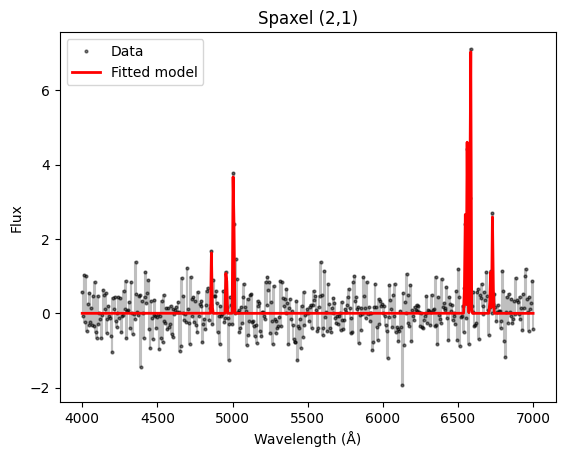

In [18]:
# Extract one spaxel and verify visually
j, i = 2, 1

modelij = fitted_model[j, i].model
y_fit = modelij(cube.wave)

plt.figure()

plt.plot(cube.wave, cube.data[:, j, i], drawstyle='steps-mid', color='gray', alpha=0.5)
plt.plot(cube.wave, cube.data[:, j, i], 'k.', markersize=4, alpha=0.5, label='Data')
plt.plot(cube.wave, y_fit, 'r-', lw=2, label='Fitted model')

plt.title(f"Spaxel ({j},{i})")
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.legend()
plt.show()

In [19]:
# Evaluate the full model cube
model_cube = fitted_model(cube.wave)

In [20]:
# Look at the parameters list
fitted_model.param_names

('amp_hb',
 'amp_oiii',
 'amp_nii',
 'amp_ha',
 'amp_sii6716',
 'amp_sii6731',
 'offset',
 'fwhm',
 'redshift')

In [21]:
# Access the parameter map
fitted_model.amp_oiii.value

array([[1.63943032e+00, 3.83326589e+00, 8.00311531e+00, 4.73840844e+01,
        1.63164919e+01, 5.42528857e+00, 9.18180672e+01, 5.13461874e+01,
        5.71236903e+01, 2.52273924e+01],
       [1.55940870e+01, 4.38515255e+01, 8.20911541e+00, 3.03028582e+01,
        3.73865328e+01, 4.89784164e+01, 4.41071286e+00, 3.00794734e+01,
        7.31690418e+01, 1.61788360e+02],
       [8.76466975e+00, 8.16729019e+00, 4.26391604e+00, 2.04598039e+01,
        6.83276538e+00, 2.14394930e+01, 6.88530844e+01, 3.25861671e+00,
        7.00587658e+00, 3.58115286e+01],
       [9.15355518e+00, 4.57432978e+00, 9.50711792e+00, 2.31787131e+01,
        1.89876386e+01, 5.69856064e+01, 8.43200214e+00, 5.95718196e+01,
        1.87187790e+00, 5.32554687e+00],
       [5.22142790e+00, 4.16054303e+00, 5.42794524e+00, 1.14324389e+01,
        8.77928821e+00, 1.00000000e+03, 5.24198811e+01, 5.20979085e+01,
        1.98327616e+01, 1.95307010e+01],
       [2.42221949e+00, 7.53434587e+00, 1.69506693e+00, 1.11116118e+00,
   

In [22]:
# Access the standard deviation of the parameter map (if returned by the fitter with the covariance)
fitted_model.amp_oiii.std

array([[5.10894624e-01, 1.48203844e+01, 9.62948004e+00, 5.47228429e+01,
        9.47471131e+01, 3.39101736e+01, 5.35620064e+01, 4.16762436e+02,
        8.41667968e+01, 2.92226953e+01],
       [7.44490350e+01, 2.18158008e+02, 9.74620754e+00, 1.93676184e+01,
        5.68138316e+00, 1.97595151e+01, 2.13878401e+00, 6.31354147e+01,
        4.85731489e+01, 1.98310802e+02],
       [2.13098910e+01, 1.43114463e+00, 1.15044367e+00, 2.94330589e+00,
        7.40744515e-01, 1.37139779e+00, 3.78453123e+00, 6.09279654e-01,
        1.72285315e+00, 2.57082415e+01],
       [2.81993620e+00, 1.06389752e+00, 1.45794481e+00, 1.16735094e+00,
        1.50973299e+00, 5.71753820e+00, 8.25875481e-01, 3.59666284e+00,
        7.96974203e-01, 1.64793335e+00],
       [1.65577303e+00, 1.31206221e+00, 1.88403916e+00, 1.96414755e+00,
        3.26657077e+00, 8.08955716e+03, 2.32682893e+01, 3.95321595e+00,
        1.62087715e+00, 1.60241869e+00],
       [7.65429729e-01, 1.70897845e+00, 7.27470863e-01, 4.92131524e-01,
   

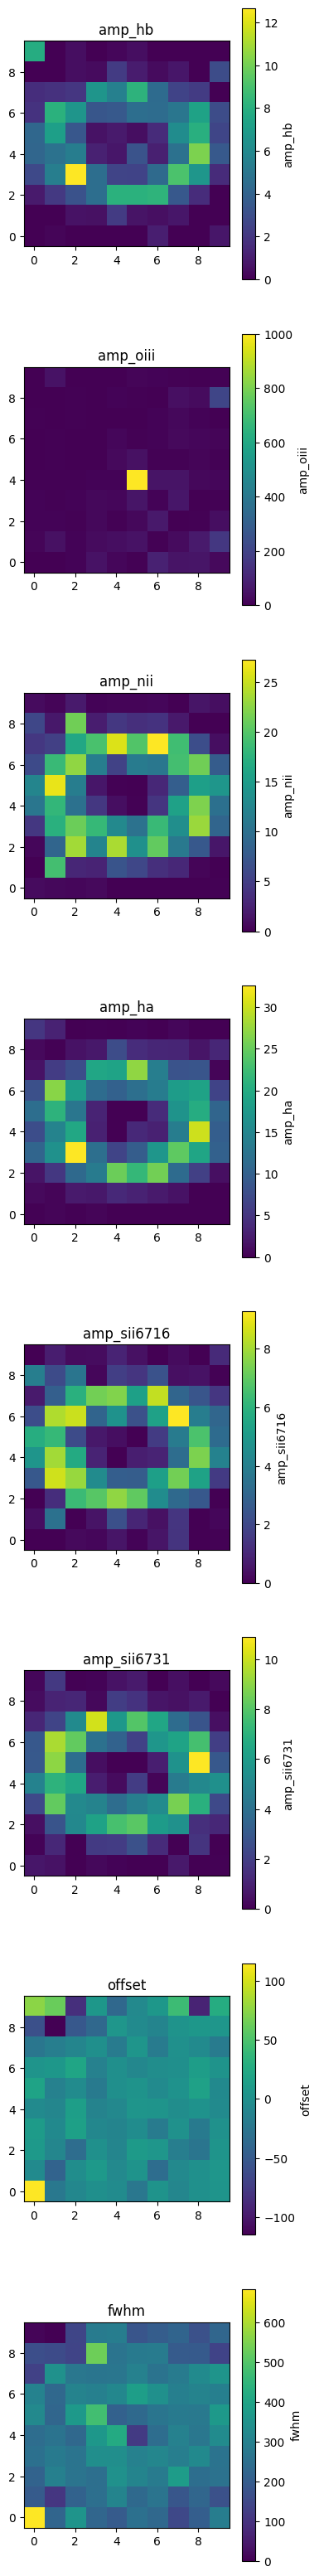

In [23]:
# Plot a map for every free parameter

if len(np.unique(fitted_model.nfree)) > 1:
    raise ValueError("The number of free parameters varies across the cube.")
nfree = int(np.unique(fitted_model.nfree)[0])

# Show the parameter maps
fig, axes = plt.subplots(figsize=(4, 5*nfree), nrows=nfree)

iplot = 0
for param in fitted_model.param_names:
    p = getattr(fitted_model, param)
    if not p.fixed:
        parmap = p.value
        axes[iplot].imshow(parmap, origin='lower')
        axes[iplot].set_title(param)
        # Add colorbar
        plt.colorbar(axes[iplot].images[0], ax=axes[iplot], label=param)
        iplot += 1

plt.show()

In [24]:
# Save the results to a FITS file
outfile = "results/cubemodel.fits"
fitted_model.save(filename=outfile,
                  wcs=cube.wcs,
                  overwrite=True,

                  # Use the ESO convention when writing the WCS (i.e. CD instead of PC matrix)
                  cd_matrix=True,

                  # Write the error maps if available?
                  std=False,

                  # Write the binary best-fit model? It can be used to re-start the fitting session
                  model=True,

                  # Add any optiona extension simply passin the extension name and value as a keyword argument
                  CHISQ=fitted_model.cost
                  )